# Linear Dynamical System Model for AVB activity

## Modelling AVB's calcium response from ASH, AVA, and AVD

### Key idea
- **Fast (instantaneous) coupling** $a_i$ — maps to **electrical synapses (gap junctions)**
- **Slow (leaky-integrator) coupling** $b_i$, $\tau_i$ — maps to **chemical synapses**
  
### Connectivity constraints (→ AVB)

| Neuron | Gap junction (fast $a_i$) | Chemical synapse (slow $b_i$) |
|--------|:------------------------:|:----------------------------:|
| ASH    | ✗ → $a_{\text{ASH}}=0$  | ✓ → $b_{\text{ASH}}$ free   |
| AVA    | ✓ → $a_{\text{AVA}}$ free | ✓ → $b_{\text{AVA}}$ free   |
| AVD    | ✓ → $a_{\text{AVD}}$ free | ✗ → $b_{\text{AVD}}=0$       |

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, differential_evolution
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

sns.set_context('notebook', font_scale=1.1)
sns.set_style('ticks')
%matplotlib inline

colors = {'ASH': '#E74C3C', 'AVA': '#3498DB', 'AVB': '#2ECC71', 'AVD': '#9B59B6'}

## Load Data & Compute Mean Traces

In [11]:
ASH = np.load('./ASH_Dauer_signal_260212.npy')  # (15, 200)
AVA = np.load('./AVA_Dauer_signal_260212.npy')  # (35, 200)
AVB = np.load('./AVB_Dauer_signal_260212.npy')  # (35, 200)
AVD = np.load('./AVD_Dauer_signal_260305.npy')  # (61, 200)
ASH_adult = np.load('./ASH_Adult_signal_260212.npy')
AVA_adult = np.load('./AVA_Adult_signal_260212.npy')
AVB_adult = np.load('./AVB_Adult_signal_260212.npy')
AVD_adult = np.load('./AVD_Adult_signal_260305.npy')

# Mean traces — used as population-level input signals
ash_mean = ASH.mean(axis=0)
ava_mean = AVA.mean(axis=0)
avb_mean = AVB.mean(axis=0)
avd_mean = AVD.mean(axis=0)
ash_mean_adult = ASH_adult.mean(axis=0)
ava_mean_adult = AVA_adult.mean(axis=0)
avb_mean_adult = AVB_adult.mean(axis=0)
avd_mean_adult = AVD_adult.mean(axis=0)

T = len(avb_mean)
t = np.arange(T)
dt = 1.0  # frame-based time step

inputs = {'ASH': ash_mean, 'AVA': ava_mean, 'AVD': avd_mean}

print(f'Timepoints: {T}')
for name, arr in [('ASH', ASH), ('AVA', AVA), ('AVB', AVB), ('AVD', AVD)]:
    print(f'  {name}: n={arr.shape[0]} animals')

Timepoints: 200
  ASH: n=15 animals
  AVA: n=35 animals
  AVB: n=35 animals
  AVD: n=61 animals


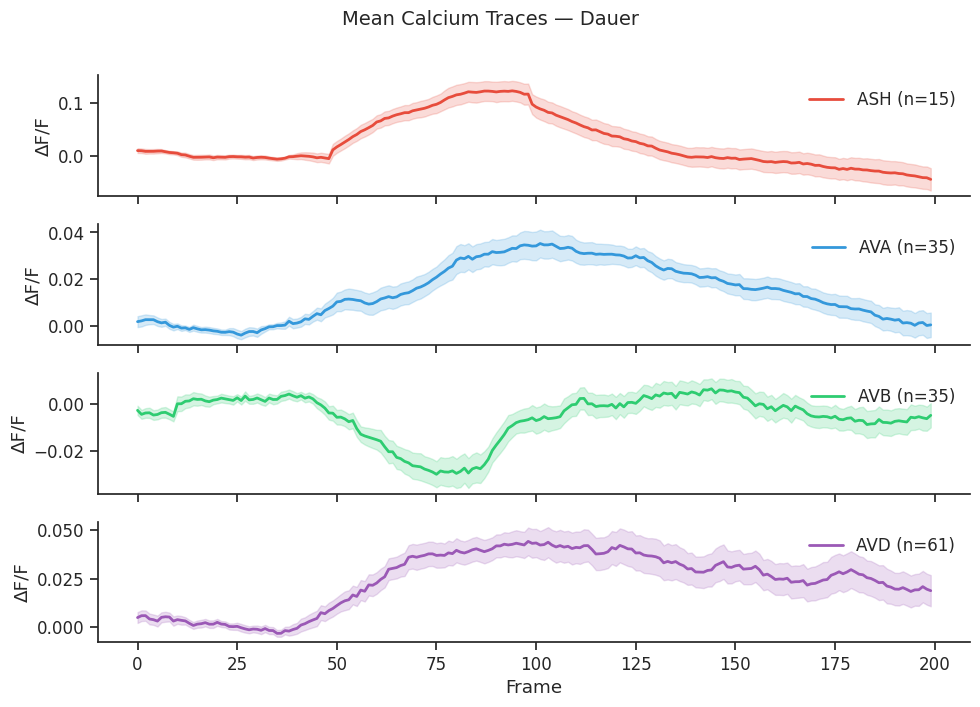

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, (name, arr) in zip(axes, [('ASH', ASH), ('AVA', AVA), ('AVB', AVB), ('AVD', AVD)]):
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0) / np.sqrt(arr.shape[0])
    ax.fill_between(t, mean - sem, mean + sem, alpha=0.2, color=colors[name])
    ax.plot(t, mean, color=colors[name], lw=2, label=f'{name} (n={arr.shape[0]})')
    ax.set_ylabel('ΔF/F')
    ax.legend(loc='upper right', frameon=False)
    sns.despine(ax=ax)
axes[-1].set_xlabel('Frame')
fig.suptitle('Mean Calcium Traces — Dauer', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Two-Timescale Model: Core Functions

### General model (Meng et al. extended to multiple inputs)

$$x_{\text{AVB}}(t) = \sum_i a_i \cdot x_i(t) + \sum_i b_i \cdot y_i(t)$$

$$\frac{dy_i}{dt} = -\frac{1}{\tau_i} \cdot y_i + x_i$$

where $i \in \{\text{ASH, AVA, AVD}\}$.

- $a_i$: fast (electrical/gap-junction) coupling strength
- $b_i$: slow (chemical synapse) coupling strength  
- $\tau_i$: integration time constant for the slow component
- $y_i$: leaky-integrated (slow) copy of neuron $i$'s activity

In [13]:
def simulate_slow_integrator(x_input, tau, dt=1.0):
    """Simulate the leaky integrator: dy/dt = -y/tau + x_input.
    
    Uses exact exponential integration for numerical stability.
    """
    T = len(x_input)
    y = np.zeros(T)
    if tau <= 0:
        return y
    decay = np.exp(-dt / tau)
    for i in range(1, T):
        y[i] = decay * y[i-1] + dt * x_input[i-1]
    return y


def predict_avb_feedforward(params, x_ash, x_ava, x_avd, dt=1.0, constrained=True):
    """Predict AVB using feedforward two-timescale model.
    
    Constrained (6 params): a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA
    Unconstrained (9 params): a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD
    """
    if constrained:
        a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA = params
        a_ASH = 0.0
        b_AVD = 0.0
        tau_AVD = 1.0  # dummy, not used
    else:
        a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD = params
    
    # Fast (instantaneous) components
    fast = a_ASH * x_ash + a_AVA * x_ava + a_AVD * x_avd
    
    # Slow (leaky-integrator) components
    y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
    y_ava = simulate_slow_integrator(x_ava, tau_AVA, dt)
    y_avd = simulate_slow_integrator(x_avd, tau_AVD, dt)
    
    slow = b_ASH * y_ash + b_AVA * y_ava + b_AVD * y_avd
    
    return fast + slow


def loss_feedforward(params, x_ash, x_ava, x_avd, target, dt=1.0, constrained=True):
    """Mean squared error loss."""
    pred = predict_avb_feedforward(params, x_ash, x_ava, x_avd, dt, constrained)
    return np.mean((pred - target) ** 2)


print('Core functions defined.')

Core functions defined.


## Model A — Constrained Feedforward (6 parameters)

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + a_{\text{AVD}} \cdot x_{\text{AVD}}
+ b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

Connectivity constraints enforced:
- $a_{\text{ASH}} = 0$ (no gap junction ASH↔AVB)
- $b_{\text{AVD}} = 0$ (no chemical synapse AVD→AVB)

In [14]:
# --- Fit constrained feedforward model ---
# Parameters: [a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA]

bounds_constrained = [
    (-2, 2),      # a_AVA
    (-2, 2),      # a_AVD
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH (frames)
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA (frames)
]

result_constrained = differential_evolution(
    loss_feedforward, bounds_constrained,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt, True),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_constrained = predict_avb_feedforward(
    result_constrained.x, ash_mean, ava_mean, avd_mean, dt, constrained=True
)
r2_constrained = r2_score(avb_mean, pred_constrained)

param_names_c = ['a_AVA', 'a_AVD', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA']
print('=== Model A: Constrained Feedforward (6 params) ===')
print(f'R² = {r2_constrained:.4f}')
print(f'MSE = {result_constrained.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_c, result_constrained.x):
    print(f'  {name:>6s} = {val:+.4f}')

=== Model A: Constrained Feedforward (6 params) ===
R² = 0.8688
MSE = 0.00001205

Fitted parameters:
   a_AVA = -0.4828
   a_AVD = -0.9384
   b_ASH = +0.0014
   τ_ASH = +61.2407
   b_AVA = +0.1024
   τ_AVA = +14.2235


## Model A-1 — Constrained Feedforward with adult inputs (6 parameters)

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + a_{\text{AVD}} \cdot x_{\text{AVD}}
+ b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

Connectivity constraints enforced:
- $a_{\text{ASH}} = 0$ (no gap junction ASH↔AVB)
- $b_{\text{AVD}} = 0$ (no chemical synapse AVD→AVB)

In [45]:
# --- Fit constrained feedforward model ---
# Parameters: [a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA]

bounds_constrained = [
    (-2, 2),      # a_AVA
    (-2, 2),      # a_AVD
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH (frames)
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA (frames)
]

result_constrained = differential_evolution(
    loss_feedforward, bounds_constrained,
    args=(ash_mean_adult, ava_mean_adult, avd_mean_adult, avb_mean, dt, True),
    seed=42, maxiter=2000, tol=1e-6, polish=True
)

pred_constrained = predict_avb_feedforward(
    result_constrained.x, ash_mean_adult, ava_mean_adult, avd_mean_adult, dt, constrained=True
)
r2_constrained = r2_score(avb_mean, pred_constrained)

param_names_c = ['a_AVA', 'a_AVD', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA']
print('=== Model A: Constrained Feedforward (6 params) ===')
print(f'R² = {r2_constrained:.4f}')
print(f'MSE = {result_constrained.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_c, result_constrained.x):
    print(f'  {name:>6s} = {val:+.4f}')

ValueError: Input contains NaN.

In [44]:
result_constrained

             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: nan
                   x: [-4.201e-01 -1.543e+00 -5.987e-01  5.514e+01
                       -1.675e+00  7.389e+00]
                 nit: 5000
                nfev: 450237
          population: [[-4.201e-01 -1.543e+00 ... -1.675e+00  7.389e+00]
                       [-1.983e+00 -1.197e+00 ... -2.855e-01  7.860e+01]
                       ...
                       [-5.450e-03 -1.071e+00 ...  1.261e+00  9.602e+01]
                       [ 2.245e-01 -1.028e+00 ... -1.543e+00  1.428e+01]]
 population_energies: [       nan        nan ...        nan        nan]

## Model B — Minimal Electrical Connectivity (5 parameters)

What if AVD↔AVB and ASH↔AVD **do not** have functional electrical synapses?
This reduces to only **AVA↔AVB** having a gap junction.

| Neuron | Gap junction (fast $a_i$) | Chemical synapse (slow $b_i$) |
|--------|:------------------------:|:----------------------------:|
| ASH    | ✗ → $a_{\text{ASH}}=0$  | ✓ → $b_{\text{ASH}}$ free   |
| AVA    | ✓ → $a_{\text{AVA}}$ free | ✓ → $b_{\text{AVA}}$ free   |
| AVD    | ✗ → $a_{\text{AVD}}=0$  | ✗ → $b_{\text{AVD}}=0$       |

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

5 free parameters: $a_{\text{AVA}}, b_{\text{ASH}}, \tau_{\text{ASH}}, b_{\text{AVA}}, \tau_{\text{AVA}}$.

This is the most parsimonious model — and closest to the original Meng et al.
single-input model, now extended with ASH chemical input.

Comparing B vs A directly tests **whether the AVD gap junction contributes**.

In [15]:
def predict_avb_minimal(params, x_ash, x_ava, x_avd, dt=1.0):
    """Predict AVB with minimal electrical connectivity.
    
    Only AVA↔AVB gap junction; no AVD↔AVB, no ASH↔AVB electrical.
    Parameters (5): a_AVA, b_ASH, tau_ASH, b_AVA, tau_AVA
    """
    a_AVA, b_ASH, tau_ASH, b_AVA, tau_AVA = params
    
    # Fast: only AVA
    fast = a_AVA * x_ava
    
    # Slow: ASH chemical + AVA chemical/extrasynaptic
    y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
    y_ava = simulate_slow_integrator(x_ava, tau_AVA, dt)
    slow = b_ASH * y_ash + b_AVA * y_ava
    
    return fast + slow


def loss_minimal(params, x_ash, x_ava, x_avd, target, dt=1.0):
    pred = predict_avb_minimal(params, x_ash, x_ava, x_avd, dt)
    return np.mean((pred - target) ** 2)


bounds_minimal = [
    (-2, 2),      # a_AVA
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA
]

result_minimal = differential_evolution(
    loss_minimal, bounds_minimal,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_minimal = predict_avb_minimal(
    result_minimal.x, ash_mean, ava_mean, avd_mean, dt
)
r2_minimal = r2_score(avb_mean, pred_minimal)

param_names_m = ['a_AVA', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA']
print('=== Model D: Minimal Electrical (5 params) ===')
print(f'R² = {r2_minimal:.4f}')
print(f'MSE = {result_minimal.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_m, result_minimal.x):
    print(f'  {name:>6s} = {val:+.4f}')

# Direct comparison: does the AVD gap junction matter?
print(f'\n--- AVD gap junction contribution ---')
print(f'  Model A (with AVD gap jn):    R² = {r2_constrained:.4f}  (6 params)')
print(f'  Model D (without AVD gap jn): R² = {r2_minimal:.4f}  (5 params)')
print(f'  ΔR² = {r2_constrained - r2_minimal:+.4f}')

=== Model D: Minimal Electrical (5 params) ===
R² = 0.6160
MSE = 0.00003527

Fitted parameters:
   a_AVA = -1.6196
   b_ASH = +0.0230
   τ_ASH = +52.3221
   b_AVA = -0.1119
   τ_AVA = +6.5382

--- AVD gap junction contribution ---
  Model A (with AVD gap jn):    R² = 0.8688  (6 params)
  Model D (without AVD gap jn): R² = 0.6160  (5 params)
  ΔR² = +0.2529


## Model C — With AVA Extrasynaptic Input (5 parameters)

Adds the Meng et al. extrasynaptic slow excitation from AVA:

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

5 free parameters: $a_{\text{AVA}}, b_{\text{ASH}}, \tau_{\text{ASH}}, b_{\text{AVA}}, \tau_{\text{AVA}}$

In [16]:
def predict_avb_adult_extrasyn(params, x_ash, x_ava, x_avd, dt=1.0):
    """Adult model with AVA extrasynaptic input."""
    a_AVA, b_ASH, tau_ASH, b_AVA, tau_AVA = params
    fast = a_AVA * x_ava
    y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
    y_ava = simulate_slow_integrator(x_ava, tau_AVA, dt)
    slow = b_ASH * y_ash + b_AVA * y_ava
    return fast + slow

def loss_adult_extrasyn(params, x_ash, x_ava, x_avd, target, dt=1.0):
    pred = predict_avb_adult_extrasyn(params, x_ash, x_ava, x_avd, dt)
    return np.mean((pred - target) ** 2)

bounds_adult_extrasyn = [
    (-2, 2),   # a_AVA
    (-2, 2),   # b_ASH
    (1, 100),  # tau_ASH
    (-2, 2),   # b_AVA
    (1, 100),  # tau_AVA
]

res_ad_extrasyn = differential_evolution(
    loss_adult_extrasyn, bounds_adult_extrasyn,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_ad_extrasyn = predict_avb_adult_extrasyn(res_ad_extrasyn.x, ash_mean, ava_mean, avd_mean)
r2_ad_extrasyn = r2_score(avb_mean, pred_ad_extrasyn)

print('=== Model B_adult: + AVA Extrasynaptic (5 params) ===')
print(f'R² = {r2_ad_extrasyn:.4f}')
print(f'MSE = {res_ad_extrasyn.fun:.8f}')
for name, val in zip(['a_AVA', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA'], res_ad_extrasyn.x):
    print(f'  {name:>6s} = {val:+.4f}')

print(f'\n--- Does AVA extrasynaptic input help? ---')
print(f'  A_adult (without): R² = {r2_ad_strict:.4f}  (3 params)')
print(f'  B_adult (with):    R² = {r2_ad_extrasyn:.4f}  (5 params)')
print(f'  ΔR² = {r2_ad_extrasyn - r2_ad_strict:+.4f}')

=== Model B_adult: + AVA Extrasynaptic (5 params) ===
R² = 0.6160
MSE = 0.00003527
   a_AVA = -1.6196
   b_ASH = +0.0230
   τ_ASH = +52.3221
   b_AVA = -0.1119
   τ_AVA = +6.5382

--- Does AVA extrasynaptic input help? ---


NameError: name 'r2_ad_strict' is not defined

## Compare

In [ ]:
colormap = sns.color_palette("colorblind")

# --- All four models compared ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t, avb_mean, 'k-', lw=2.5, label='AVB observed (mean)', zorder=5)
ax.plot(t, pred_constrained, '--', color=colormap[0], lw=1.5,
        label=f'Circuit constrained (R²={r2_constrained:.3f})')
ax.plot(t, pred_minimal, '-', color=colormap[1], lw=1.5, alpha=0.8,
        label=f'No AVB-AVD gap (R²={r2_minimal:.3f})')
ax.set_xlim(0,200)
ax.set_xlabel('Frame', fontsize=20)
ax.set_ylabel('ΔF/F', fontsize=20)
# ax.set_title('Two-Timescale Models — Predicting Mean AVB Trace')
ax.legend(frameon=False, fontsize=9, prop={"size":13})
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Ablation analysis: set each parameter to zero and measure R² drop
p_best = result_constrained.x.copy()

ablation_results = {}
pathway_labels = {
    0: 'AVA gap junction (a_AVA)',
    1: 'AVD gap junction (a_AVD)',
    2: 'ASH chemical (b_ASH)',
    4: 'AVA chemical (b_AVA)',
}

print(f'{"Ablated pathway":35s} {"R²":>8s} {"ΔR²":>8s}')
print('-' * 55)
print(f'{"None (full model)":35s} {r2_constrained:8.4f} {"—":>8s}')

for idx, label in pathway_labels.items():
    p_ablated = p_best.copy()
    p_ablated[idx] = 0.0
    pred_abl = predict_avb_feedforward(p_ablated, ash_mean, ava_mean, avd_mean, dt, constrained=True)
    r2_abl = r2_score(avb_mean, pred_abl)
    ablation_results[label] = r2_constrained - r2_abl
    print(f'{label:35s} {r2_abl:8.4f} {r2_constrained - r2_abl:+8.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
labels = list(ablation_results.keys())
deltas = list(ablation_results.values())
bar_colors = [colors['AVA'], colors['AVD'], colors['ASH'], colors['AVA']]
ax.barh(labels, deltas, color=bar_colors, edgecolor='white', height=0.6)
ax.set_xlabel('ΔR² (drop when ablated)')
ax.set_title('Ablation Analysis')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# Figure: AVB Two-Timescale Model — Manuscript Panels
# =============================================================================
# Panel A  — Two-timescale model schematic (matplotlib patch diagram)
# Panel B  — Connectivity-constrained fit vs. no AVD gap junction
# Panel C  — Ablation study (ΔR² bar chart)
# =============================================================================

import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

# ── Shared style ──────────────────────────────────────────────────────────────
COLORS = {
    'fast':   '#1D9E75',   # teal  — fast / gap-junction pathway
    'slow':   '#7F77DD',   # purple — slow / chemical synapse pathway
    'avb':    '#444441',   # dark gray — AVB neuron
    'data':   '#2C2C2A',   # near-black — observed trace
    'fit_c':  '#378ADD',   # blue  — constrained model fit
    'fit_nc': '#D85A30',   # coral — no-AVD-gap model fit
    'bar_ava_gap': '#3498DB',
    'bar_avd_gap': '#9B59B6',
    'bar_ash_chem':'#E74C3C',
    'bar_ava_chem':'#3498DB',
}

fig = plt.figure(figsize=(15, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.38, left=0.04, right=0.97,
                        top=0.90, bottom=0.12)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — Two-timescale model schematic
# ─────────────────────────────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])
ax_a.set_xlim(0, 1)
ax_a.set_ylim(0, 1)
ax_a.axis('off')
ax_a.set_aspect('equal')

def draw_box(ax, x, y, w, h, label, sublabel=None, color='#E1F5EE',
             edgecolor='#1D9E75', fontsize=9, lw=1.0):
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle='round,pad=0.02',
                          facecolor=color, edgecolor=edgecolor,
                          linewidth=lw, zorder=3)
    ax.add_patch(box)
    cy = y + h/2 + (0.025 if sublabel else 0)
    ax.text(x + w/2, cy, label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='#1a1a1a', zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.04, sublabel,
                ha='center', va='center', fontsize=7.5,
                color='#444441', zorder=4)

def arrow(ax, x0, y0, x1, y1, color, lw=1.4, style='solid', hw=0.012, hl=0.018):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle=f'->,head_width={hw},head_length={hl}',
                                color=color, lw=lw,
                                linestyle=style,
                                connectionstyle='arc3,rad=0.0'))

# Background bands
ax_a.add_patch(mpatches.FancyBboxPatch(
    (0.03, 0.54), 0.94, 0.40,
    boxstyle='round,pad=0.01',
    facecolor='#EEEDFE', edgecolor='#AFA9EC', lw=0.7, zorder=1))
ax_a.add_patch(mpatches.FancyBboxPatch(
    (0.03, 0.08), 0.94, 0.40,
    boxstyle='round,pad=0.01',
    facecolor='#E1F5EE', edgecolor='#5DCAA5', lw=0.7, zorder=1))

ax_a.text(0.07, 0.90, 'Slow  (τ ~ min)', fontsize=8, color='#534AB7',
          fontweight='bold', va='center')
ax_a.text(0.07, 0.44, 'Fast  (τ ~ s)',   fontsize=8, color='#0F6E56',
          fontweight='bold', va='center')

# Slow box
draw_box(ax_a, 0.28, 0.60, 0.44, 0.22,
         'Chemical synapses', 'ASH, AVA → AVB',
         color='#CECBF6', edgecolor='#7F77DD')

# Fast box
draw_box(ax_a, 0.28, 0.14, 0.44, 0.22,
         'Gap junctions', 'AVA, AVD → AVB',
         color='#9FE1CB', edgecolor='#1D9E75')

# AVB box
draw_box(ax_a, 0.34, -0.08, 0.32, 0.18,
         'AVB', 'Ca²⁺ activity',
         color='#D3D1C7', edgecolor='#5F5E5A', lw=1.2)

# Slow → AVB
arrow(ax_a, 0.50, 0.60, 0.44, 0.10,
      color=COLORS['slow'], lw=1.6, style='dashed')

# Fast → AVB
arrow(ax_a, 0.50, 0.14, 0.46, 0.10,
      color=COLORS['fast'], lw=1.6)

# GJ_d badge on slow arrow
ax_a.add_patch(mpatches.FancyBboxPatch(
    (0.56, 0.30), 0.135, 0.085,
    boxstyle='round,pad=0.015',
    facecolor='#FAEEDA', edgecolor='#EF9F27', lw=1.0, zorder=5))
ax_a.text(0.627, 0.343, 'GJ_d', ha='center', va='center',
          fontsize=8.5, fontweight='bold', color='#633806', zorder=6)
# small leader dot to slow arrow
ax_a.plot([0.555, 0.50], [0.343, 0.40], color='#EF9F27', lw=0.8,
          linestyle=':', zorder=4)

# Output arrow
arrow(ax_a, 0.50, -0.08, 0.50, -0.15,
      color='#888780', lw=1.2)
ax_a.text(0.50, -0.17, 'motor output', ha='center', va='top',
          fontsize=7.5, color='#5F5E5A')

# Legend
ax_a.plot([0.08, 0.17], [0.005, 0.005], color=COLORS['fast'], lw=1.8, label='fast (gap jn.)')
ax_a.plot([0.30, 0.39], [0.005, 0.005], color=COLORS['slow'], lw=1.8,
          linestyle='dashed', label='slow (chem. syn.)')
ax_a.text(0.18, 0.005, 'fast (gap jn.)', va='center', fontsize=7.5, color=COLORS['fast'])
ax_a.text(0.40, 0.005, 'slow / GJ_d',   va='center', fontsize=7.5, color=COLORS['slow'])

ax_a.set_title('A', fontsize=13, fontweight='bold', loc='left', pad=4, x=-0.02)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Model fit comparison
# ─────────────────────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])

sem_avb = AVB.std(axis=0) / np.sqrt(AVB.shape[0])
ax_b.fill_between(t, avb_mean - sem_avb, avb_mean + sem_avb,
                   alpha=0.18, color=COLORS['data'])
ax_b.plot(t, avb_mean,        color=COLORS['data'],   lw=2.0,
          label='AVB observed', zorder=5)
ax_b.plot(t, pred_constrained, color=COLORS['fit_c'],  lw=1.8, ls='--',
          label=f'Circuit-constrained  $R^2$={r2_constrained:.3f}', zorder=4)
ax_b.plot(t, pred_minimal,     color=COLORS['fit_nc'], lw=1.8, ls='-.',
          label=f'No AVD gap junction  $R^2$={r2_minimal:.3f}', zorder=3)

ax_b.set_xlabel('Frame', fontsize=11)
ax_b.set_ylabel('ΔF/F', fontsize=11)
ax_b.set_xlim(0, 200)
ax_b.legend(frameon=False, fontsize=8.5, loc='upper right')
sns.despine(ax=ax_b)
ax_b.set_title('B', fontsize=13, fontweight='bold', loc='left', pad=4)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Ablation study
# ─────────────────────────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[2])

bar_colors = [
    COLORS['bar_ava_gap'],
    COLORS['bar_avd_gap'],
    COLORS['bar_ash_chem'],
    COLORS['bar_ava_chem'],
]
short_labels = [
    'AVA gap jn.\n($a_{AVA}$)',
    'AVD gap jn.\n($a_{AVD}$)',
    'ASH chemical\n($b_{ASH}$)',
    'AVA chemical\n($b_{AVA}$)',
]
deltas = list(ablation_results.values())

bars = ax_c.barh(short_labels, deltas,
                  color=bar_colors, edgecolor='white',
                  height=0.55, zorder=3)

for bar, val in zip(bars, deltas):
    ax_c.text(val + 0.002, bar.get_y() + bar.get_height()/2,
              f'{val:.3f}', va='center', fontsize=8.5)

ax_c.set_xlabel('ΔR² (drop when ablated)', fontsize=11)
ax_c.axvline(0, color='#888780', lw=0.8)
ax_c.invert_yaxis()
sns.despine(ax=ax_c)
ax_c.set_title('C', fontsize=13, fontweight='bold', loc='left', pad=4)

plt.savefig('AVB_figure_panels.pdf', dpi=300, bbox_inches='tight')
plt.savefig('AVB_figure_panels.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: AVB_figure_panels.pdf / .png")


In [9]:
# =============================================================================
# Panel D analysis — adult circuitry applied to dauer inputs
# Records loss per iteration via callback to show non-convergence
# =============================================================================

loss_history_dauer = []
loss_history_adult = []

def cb_dauer(xk, convergence=None):
    loss = loss_feedforward(xk, ash_mean, ava_mean, avd_mean, avb_mean, dt, constrained=True)
    loss_history_dauer.append(loss)

def cb_adult(xk, convergence=None):
    loss = loss_feedforward(xk, ash_mean_adult, ava_mean_adult, avd_mean_adult, avb_mean, dt, constrained=True)
    loss_history_adult.append(loss)

bounds_constrained = [
    (-2, 2), (-2, 2), (-2, 2),
    (1, 100), (-2, 2), (1, 100),
]

# Re-run with callbacks to capture loss trajectory
result_dauer_cb = differential_evolution(
    loss_feedforward, bounds_constrained,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt, True),
    seed=42, maxiter=300, tol=1e-12, polish=False,
    callback=cb_dauer
)

result_adult_cb = differential_evolution(
    loss_feedforward, bounds_constrained,
    args=(ash_mean_adult, ava_mean_adult, avd_mean_adult, avb_mean, dt, True),
    seed=42, maxiter=300, tol=1e-6, polish=False,
    callback=cb_adult
)

pred_adult_best = predict_avb_feedforward(
    result_adult_cb.x, ash_mean_adult, ava_mean_adult, avd_mean_adult, dt, constrained=True
)
r2_adult_best = r2_score(avb_mean, pred_adult_best)

print(f"Dauer connectivity  — final R²: {r2_score(avb_mean, pred_constrained):.4f}")
print(f"Adult connectivity  — final R²: {r2_adult_best:.4f}")
print(f"Loss history lengths: dauer={len(loss_history_dauer)}, adult={len(loss_history_adult)}")

ValueError: Input contains NaN.